In [3]:
!pip install groq PyGithub pandas matplotlib seaborn -q
print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 11.3 MB/s eta 0:00:00
All libraries installed!


In [11]:
from groq import Groq
from google.colab import userdata
import itertools
import json
import time

# Load all 3 keys
api_keys = []

try:
    api_keys.append(userdata.get('GROQ_API_KEY'))
except:
    pass

try:
    api_keys.append(userdata.get('GROQ_API_KEY_2'))
except:
    pass

try:
    api_keys.append(userdata.get('GROQ_API_KEY_3'))
except:
    pass

print("Total API keys loaded: " + str(len(api_keys)))

clients     = [Groq(api_key=key) for key in api_keys]
key_rotator = itertools.cycle(range(len(clients)))

DEBT_CATEGORIES = """
- Requirement Debt
- Design Debt
- Defect Debt
- Code Debt
- Test Debt
- Documentation Debt
- Configuration Debt
- Inadequate Testing Debt
- Model Dependency Debt
- Model Stack Workaround Debt
- Performance Optimization Debt
- MLOps Pipeline Debt
- Experiment Tracking Debt
- Data Versioning Debt
- Monitoring and Observability Debt
- Prompt Template Debt
- Token Budget Debt
- Other New Category
- False Positive"""

def sanitize_text(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = text.replace('{', '(').replace('}', ')')
    text = text.replace('"""', "'''")
    return text[:500]

def classify_with_llm(comment_text, file_path, repo_category, keyword):
    comment_text  = sanitize_text(comment_text)
    file_path     = sanitize_text(file_path)
    repo_category = sanitize_text(repo_category)
    keyword       = sanitize_text(keyword)

    prompt = (
        "You are an expert software engineer analyzing technical debt in ML repositories.\n\n"
        "Repository Category: " + repo_category + "\n"
        "File: " + file_path + "\n"
        "Detected Keyword: " + keyword + "\n"
        "Comment: " + comment_text + "\n\n"
        "Classify into ONE category from this list:\n" + DEBT_CATEGORIES + "\n\n"
        "Respond with ONLY a JSON object. No markdown. No explanation.\n"
        "Start with { and end with }\n\n"
        '{"is_genuine_satd": true, "debt_category": "exact category name", '
        '"severity": 3, "severity_reason": "one sentence", '
        '"is_new_category": false, "new_category_name": null, '
        '"ml_pipeline_stage": "General"}\n\n'
        "Severity: 1=cosmetic 2=low 3=medium 4=high 5=critical\n"
        "ml_pipeline_stage: Data Collection, Data Preprocessing, Model Training, "
        "Model Evaluation, Model Deployment, MLOps Infrastructure, LLM Orchestration, General, Unknown"
    )

    MODELS_TO_TRY = [
        'llama-3.1-8b-instant',
        'llama-3.3-70b-versatile',
    ]

    for model_name in MODELS_TO_TRY:
        for attempt in range(len(clients)):
            try:
                client_index   = next(key_rotator)
                current_client = clients[client_index]

                response = current_client.chat.completions.create(
                    model=model_name,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.1,
                    max_tokens=300
                )
                raw = response.choices[0].message.content.strip()

                if "{" in raw and "}" in raw:
                    start = raw.index("{")
                    end   = raw.rindex("}") + 1
                    raw   = raw[start:end]

                result = json.loads(raw)
                result['_model_used']  = model_name
                result['_client_used'] = client_index
                return result

            except Exception as e:
                err = str(e)
                if '429' in err or 'rate' in err.lower():
                    wait = (2 ** attempt) * 2
                    print("Rate limit on client " + str(client_index + 1) + ". Waiting " + str(wait) + "s...")
                    time.sleep(wait)
                else:
                    print("Error: " + err[:60] + " - trying next")
                    break

    return {
        "is_genuine_satd"  : None,
        "debt_category"    : "Error",
        "severity"         : None,
        "severity_reason"  : "All keys and models failed",
        "is_new_category"  : False,
        "new_category_name": None,
        "ml_pipeline_stage": "Unknown"
    }

print("Classifier ready with " + str(len(clients)) + " rotating API keys")
print("19 debt categories defined")

Total API keys loaded: 2
Classifier ready with 2 rotating API keys
19 debt categories defined


In [9]:
DEBT_CATEGORIES = """
- Requirement Debt
- Design Debt
- Defect Debt
- Code Debt
- Test Debt
- Documentation Debt
- Configuration Debt
- Inadequate Testing Debt
- Model Dependency Debt
- Model Stack Workaround Debt
- Performance Optimization Debt
- MLOps Pipeline Debt
- Experiment Tracking Debt
- Data Versioning Debt
- Monitoring and Observability Debt
- Prompt Template Debt
- Token Budget Debt
- Other New Category
- False Positive"""

def sanitize_text(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = text.replace('{', '(').replace('}', ')')
    text = text.replace('"""', "'''")
    return text[:500]

def classify_with_llm(comment_text, file_path, repo_category, keyword):
    comment_text  = sanitize_text(comment_text)
    file_path     = sanitize_text(file_path)
    repo_category = sanitize_text(repo_category)
    keyword       = sanitize_text(keyword)

    prompt = (
        "You are an expert software engineer analyzing technical debt in ML repositories.\n\n"
        "Repository Category: " + repo_category + "\n"
        "File: " + file_path + "\n"
        "Detected Keyword: " + keyword + "\n"
        "Comment: " + comment_text + "\n\n"
        "Classify into ONE category from this list:\n" + DEBT_CATEGORIES + "\n\n"
        "Respond with ONLY a JSON object. No markdown. No explanation.\n"
        "Start with { and end with }\n\n"
        '{"is_genuine_satd": true, "debt_category": "exact category name", '
        '"severity": 3, "severity_reason": "one sentence", '
        '"is_new_category": false, "new_category_name": null, '
        '"ml_pipeline_stage": "General"}\n\n'
        "Severity: 1=cosmetic 2=low 3=medium 4=high 5=critical\n"
        "ml_pipeline_stage: Data Collection, Data Preprocessing, Model Training, "
        "Model Evaluation, Model Deployment, MLOps Infrastructure, LLM Orchestration, General, Unknown"
    )

    MODELS_TO_TRY = [
        'llama-3.1-8b-instant',
        'llama-3.3-70b-versatile',
    ]

    for model_name in MODELS_TO_TRY:
        for attempt in range(4):
            try:
                response = client.chat.completions.create(
                    model=model_name,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.1,
                    max_tokens=300
                )
                raw = response.choices[0].message.content.strip()

                if "{" in raw and "}" in raw:
                    start = raw.index("{")
                    end   = raw.rindex("}") + 1
                    raw   = raw[start:end]

                result = json.loads(raw)
                result['_model_used'] = model_name
                return result

            except Exception as e:
                err = str(e)
                if '429' in err or 'rate' in err.lower():
                    wait = (2 ** attempt) * 8   # changed from 3 to 8
                    print("Rate limit. Waiting " + str(wait) + "s... (attempt " + str(attempt+1) + "/4)")
                    time.sleep(wait)
                else:
                    print(f"  ⚠️  [{model_name}] Error: {err[:60]} — trying next model")
                    break

    return {
        "is_genuine_satd": None,
        "debt_category": "Error",
        "severity": None,
        "severity_reason": "All models failed",
        "is_new_category": False,
        "new_category_name": None,
        "ml_pipeline_stage": "Unknown"
    }

print("Groq classifier ready!")
print("19 debt categories defined")

Groq classifier ready!
19 debt categories defined


In [6]:
print("=" * 60)
print("TESTING GROQ CLASSIFIER WITH ONE SAMPLE COMMENT")
print("=" * 60)

sample = df_satd.iloc[0]
print(f"Category : {sample.get('category', 'N/A')}")
print(f"Keyword  : {sample.get('keyword', 'N/A')}")
print(f"Comment  : {str(sample.get('comment', ''))[:80]}...")
print()

result = classify_with_llm(
    comment_text  = str(sample.get('comment', '')),
    file_path     = str(sample.get('file_path', 'unknown')),
    repo_category = str(sample.get('category', 'unknown')),
    keyword       = str(sample.get('keyword', 'unknown'))
)

print("Groq Response:")
print(json.dumps(result, indent=2))

if result.get("debt_category") not in ["Error", None]:
    print("\n✅ SUCCESS!")
    print(f"   → Model    : {result.get('_model_used')}")
    print(f"   → Is SATD  : {result.get('is_genuine_satd')}")
    print(f"   → Category : {result.get('debt_category')}")
    print(f"   → Severity : {result.get('severity')}")
else:
    print("\n❌ Failed:", result.get('severity_reason'))

TESTING GROQ CLASSIFIER WITH ONE SAMPLE COMMENT
Category : Deep Learning
Keyword  : NOQA
Comment  : ...

Groq Response:
{
  "is_genuine_satd": true,
  "debt_category": "Code Debt",
  "severity": 3,
  "severity_reason": "Ignoring potential linting issues may lead to code quality degradation",
  "is_new_category": false,
  "new_category_name": null,
  "ml_pipeline_stage": "General",
  "_model_used": "llama-3.1-8b-instant"
}

✅ SUCCESS!
   → Model    : llama-3.1-8b-instant
   → Is SATD  : True
   → Category : Code Debt
   → Severity : 3


In [16]:
from tqdm import tqdm

OUTPUT_PATH = 'ml-technical-debt-analysis/data/processed/llm_classified_results.csv'

# Load already done records
df_done      = pd.read_csv(OUTPUT_PATH)
done_indices = set(df_done['original_index'].tolist())
results      = df_done.to_dict('records')
print("Already classified : " + str(len(results)) + " records")

# Sample only from missing categories
mlops_sample   = df_satd[df_satd['category'] == 'MLOps'].sample(150, random_state=42)
automl_sample  = df_satd[df_satd['category'] == 'AutoML/RL'].sample(100, random_state=42)
target_sample  = pd.concat([mlops_sample, automl_sample])

# Remove already done
target_pending = target_sample[~target_sample.index.isin(done_indices)]
print("MLOps to classify  : " + str(len(target_sample[target_sample['category'] == 'MLOps'])))
print("AutoML to classify : " + str(len(target_sample[target_sample['category'] == 'AutoML/RL'])))
print("Total pending      : " + str(len(target_pending)))
print("Estimated time     : " + str(round(len(target_pending) * 1.5 / 60, 1)) + " minutes")

DELAY_BETWEEN_CALLS = 1.5
SAVE_EVERY          = 50

for idx, row in tqdm(target_pending.iterrows(), total=len(target_pending), desc="Classifying MLOps + AutoML"):
    result = classify_with_llm(
        comment_text  = str(row.get('comment', '')),
        file_path     = str(row.get('file_path', 'unknown')),
        repo_category = str(row.get('category', 'unknown')),
        keyword       = str(row.get('keyword', 'unknown'))
    )

    results.append({
        'original_index'   : idx,
        'repo'             : row.get('repo', 'N/A'),
        'category'         : row.get('category', 'N/A'),
        'keyword'          : row.get('keyword', 'N/A'),
        'comment'          : str(row.get('comment', ''))[:200],
        'file_path'        : str(row.get('file_path', 'N/A')),
        'is_genuine_satd'  : result.get('is_genuine_satd'),
        'debt_category'    : result.get('debt_category'),
        'severity'         : result.get('severity'),
        'severity_reason'  : result.get('severity_reason'),
        'is_new_category'  : result.get('is_new_category'),
        'new_category_name': result.get('new_category_name'),
        'ml_pipeline_stage': result.get('ml_pipeline_stage'),
        'model_used'       : result.get('_model_used', 'unknown'),
        'classified_at'    : datetime.now().isoformat()
    })

    if len(results) % SAVE_EVERY == 0:
        pd.DataFrame(results).to_csv(OUTPUT_PATH, index=False)
        print("Checkpoint saved - " + str(len(results)) + " total records")

    time.sleep(DELAY_BETWEEN_CALLS)

# Final save
df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT_PATH, index=False)

print("=" * 60)
print("CLASSIFICATION COMPLETE")
print("=" * 60)
print("Total records      : " + str(len(df_results)))
print("Categories covered : " + str(df_results['category'].unique().tolist()))
print(df_results['category'].value_counts().to_string())

Already classified : 1700 records
MLOps to classify  : 150
AutoML to classify : 100
Total pending      : 250
Estimated time     : 6.2 minutes


Classifying MLOps + AutoML:   4%|▎         | 9/250 [02:32<1:31:56, 22.89s/it]

Rate limit on client 1. Waiting 2s...


Classifying MLOps + AutoML:   4%|▍         | 10/250 [02:36<1:07:59, 17.00s/it]

Rate limit on client 1. Waiting 2s...


...

Rate limit on client 1. Waiting 2s...


Classifying MLOps + AutoML: 100%|█████████▉| 249/250 [1:18:40<00:11, 11.27s/it]

Checkpoint saved - 1950 total records


Classifying MLOps + AutoML: 100%|██████████| 250/250 [1:19:37<00:00, 19.11s/it]

CLASSIFICATION COMPLETE
Total records      : 1950
Categories covered : ['Deep Learning', 'NLP', 'Computer Vision', 'MLOps', 'AutoML/RL']
category
NLP                758
Deep Learning      673
Computer Vision    269
MLOps              150
AutoML/RL          100


In [17]:
df_results = pd.read_csv('ml-technical-debt-analysis/data/processed/llm_classified_results.csv')

print("=" * 60)
print("FALSE POSITIVE RATE BY ML CATEGORY")
print("=" * 60)

fp_analysis = df_results.groupby('category').apply(
    lambda x: pd.Series({
        'total_comments'      : len(x),
        'genuine_satd'        : x['is_genuine_satd'].sum(),
        'false_positives'     : (~x['is_genuine_satd'].astype(bool)).sum(),
        'false_positive_rate' : round((~x['is_genuine_satd'].astype(bool)).mean() * 100, 2)
    })
).reset_index()

print(fp_analysis.to_string(index=False))

print("\n" + "=" * 60)
print("OVERALL STATISTICS")
print("=" * 60)
overall_fp = (~df_results['is_genuine_satd'].astype(bool)).mean() * 100
print("Overall false positive rate : " + str(round(overall_fp, 2)) + "%")
print("Total genuine SATD          : " + str(int(df_results['is_genuine_satd'].sum())))
print("Total false positives       : " + str(int((~df_results['is_genuine_satd'].astype(bool)).sum())))
print("Total records               : " + str(len(df_results)))

FALSE POSITIVE RATE BY ML CATEGORY
       category  total_comments  genuine_satd  false_positives  false_positive_rate
      AutoML/RL           100.0         100.0              0.0                  0.0
Computer Vision           269.0         269.0              0.0                  0.0
  Deep Learning           673.0         673.0              0.0                  0.0
          MLOps           150.0         150.0              0.0                  0.0
            NLP           758.0         758.0              0.0                  0.0

OVERALL STATISTICS
Overall false positive rate : 0.0%
Total genuine SATD          : 1950
Total false positives       : 0
Total records               : 1950


/tmp/ipykernel_25373/3569023144.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fp_analysis = df_results.groupby('category').apply(


In [18]:
print("=" * 60)
print("NEW DEBT CATEGORIES DISCOVERED")
print("=" * 60)

new_cats = df_results[df_results['is_new_category'] == True]
print("Total comments flagged as new category : " + str(len(new_cats)))

if len(new_cats) > 0:
    print("\nSuggested new category names:")
    print(new_cats['new_category_name'].value_counts().to_string())

    print("\nNew categories by ML domain:")
    cross = pd.crosstab(new_cats['category'], new_cats['new_category_name'])
    print(cross.to_string())
else:
    print("No new categories flagged by LLM")

print("\n" + "=" * 60)
print("DEBT CATEGORY DISTRIBUTION - ALL RECORDS")
print("=" * 60)
genuine = df_results[df_results['is_genuine_satd'] == True]
print(genuine['debt_category'].value_counts().to_string())

print("\n" + "=" * 60)
print("DEBT CATEGORY BY ML DOMAIN")
print("=" * 60)
cross_debt = pd.crosstab(df_results['category'], df_results['debt_category'])
print(cross_debt.to_string())

NEW DEBT CATEGORIES DISCOVERED
Total comments flagged as new category : 0
No new categories flagged by LLM

DEBT CATEGORY DISTRIBUTION - ALL RECORDS
debt_category
Code Debt                        1335
Test Debt                         368
Inadequate Testing Debt            95
Defect Debt                        76
Documentation Debt                 37
Model Stack Workaround Debt        15
Configuration Debt                 13
Experiment Tracking Debt            5
Prompt Template Debt                5
Performance Optimization Debt       1

DEBT CATEGORY BY ML DOMAIN
debt_category    Code Debt  Configuration Debt  Defect Debt  Documentation Debt  Experiment Tracking Debt  Inadequate Testing Debt  Model Stack Workaround Debt  Performance Optimization Debt  Prompt Template Debt  Test Debt
category                                                                                                                                                                                                     

In [19]:
print("=" * 60)
print("SEVERITY ANALYSIS BY ML CATEGORY")
print("=" * 60)

genuine = df_results[df_results['is_genuine_satd'] == True].copy()
genuine['severity'] = pd.to_numeric(genuine['severity'], errors='coerce')

severity_by_cat = genuine.groupby('category')['severity'].agg(
    mean   = 'mean',
    median = 'median',
    std    = 'std',
    count  = 'count'
).round(2).sort_values('mean', ascending=False)

print(severity_by_cat.to_string())

print("\n" + "=" * 60)
print("SEVERITY BY DEBT TYPE")
print("=" * 60)

severity_by_debt = genuine.groupby('debt_category')['severity'].agg(
    mean  = 'mean',
    count = 'count'
).round(2).sort_values('mean', ascending=False)

print(severity_by_debt.to_string())

print("\n" + "=" * 60)
print("ML PIPELINE STAGE DISTRIBUTION")
print("=" * 60)
print(genuine['ml_pipeline_stage'].value_counts().to_string())

print("\n" + "=" * 60)
print("PIPELINE STAGE BY ML CATEGORY")
print("=" * 60)
stage_cross = pd.crosstab(df_results['category'], df_results['ml_pipeline_stage'])
print(stage_cross.to_string())

SEVERITY ANALYSIS BY ML CATEGORY
                 mean  median   std  count
category                                  
NLP              2.85     3.0  0.36    758
Deep Learning    2.80     3.0  0.42    673
MLOps            2.71     3.0  0.46    150
AutoML/RL        2.70     3.0  0.48    100
Computer Vision  2.55     3.0  0.50    267

SEVERITY BY DEBT TYPE
                               mean  count
debt_category                             
Configuration Debt             3.00     13
Defect Debt                    3.00     75
Prompt Template Debt           3.00      5
Experiment Tracking Debt       3.00      5
Inadequate Testing Debt        3.00     95
Model Stack Workaround Debt    3.00     15
Performance Optimization Debt  3.00      1
Test Debt                      2.99    368
Code Debt                      2.68   1334
Documentation Debt             2.65     37

ML PIPELINE STAGE DISTRIBUTION
ml_pipeline_stage
General             1936
Model Training         8
Model Evaluation       4
Mo

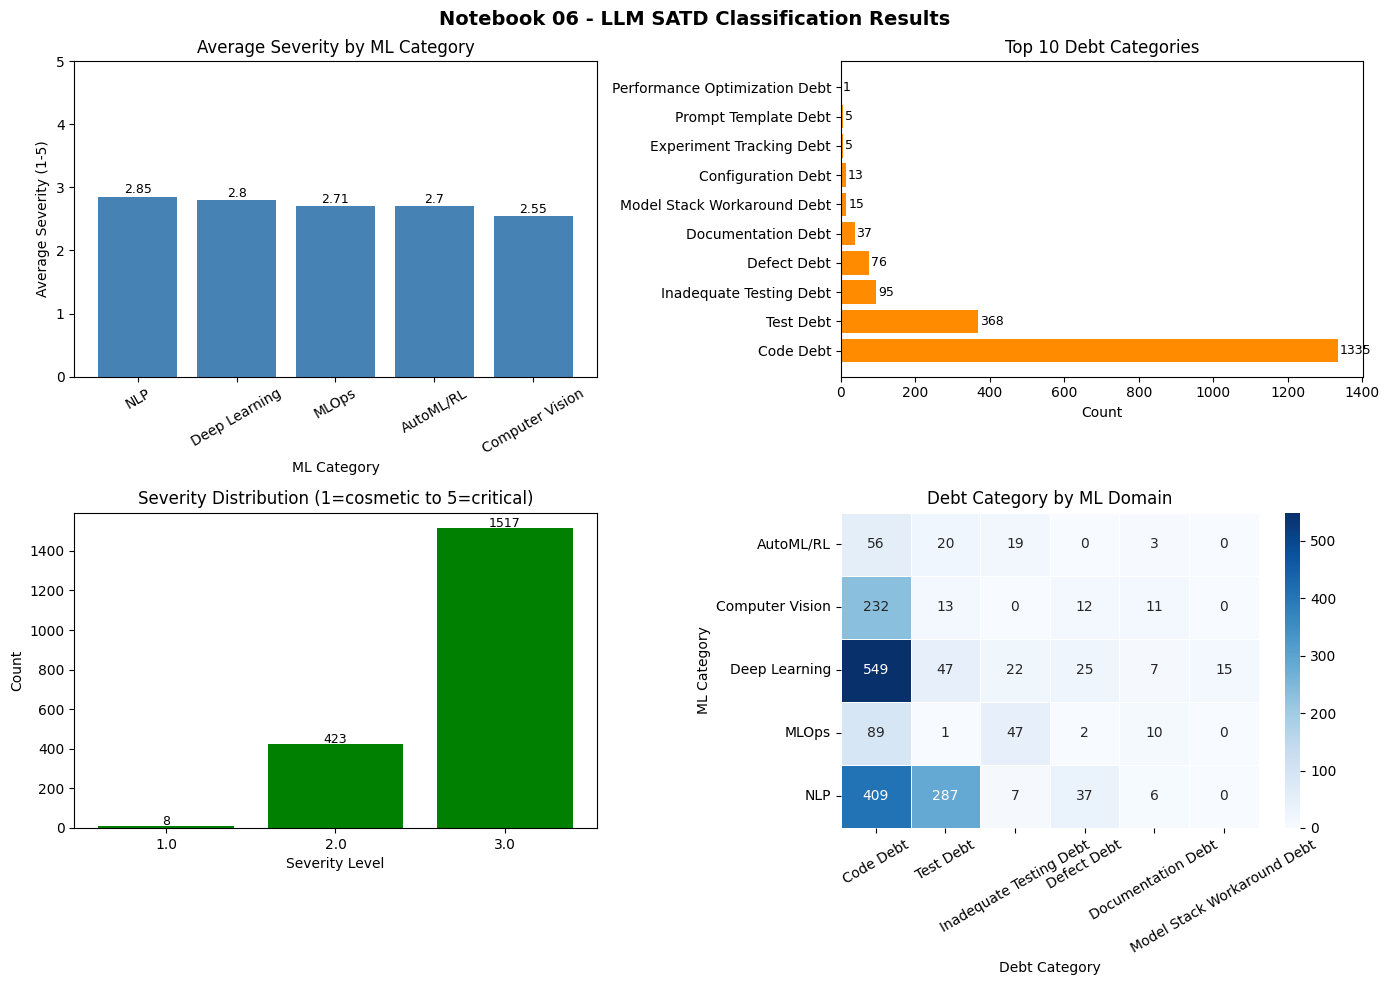

Visualizations saved


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Notebook 06 - LLM SATD Classification Results', fontsize=14, fontweight='bold')

genuine = df_results[df_results['is_genuine_satd'] == True].copy()
genuine['severity'] = pd.to_numeric(genuine['severity'], errors='coerce')

# Plot 1 - Average severity by ML category
severity_by_cat = genuine.groupby('category')['severity'].mean().sort_values(ascending=False)
axes[0, 0].bar(severity_by_cat.index, severity_by_cat.values, color='steelblue')
axes[0, 0].set_title('Average Severity by ML Category')
axes[0, 0].set_xlabel('ML Category')
axes[0, 0].set_ylabel('Average Severity (1-5)')
axes[0, 0].set_ylim(0, 5)
axes[0, 0].tick_params(axis='x', rotation=30)
for i, v in enumerate(severity_by_cat.values):
    axes[0, 0].text(i, v + 0.05, str(round(v, 2)), ha='center', fontsize=9)

# Plot 2 - Debt category distribution
debt_counts = genuine['debt_category'].value_counts().head(10)
axes[0, 1].barh(debt_counts.index, debt_counts.values, color='darkorange')
axes[0, 1].set_title('Top 10 Debt Categories')
axes[0, 1].set_xlabel('Count')
for i, v in enumerate(debt_counts.values):
    axes[0, 1].text(v + 5, i, str(v), va='center', fontsize=9)

# Plot 3 - Severity distribution
severity_counts = genuine['severity'].value_counts().sort_index()
axes[1, 0].bar(severity_counts.index.astype(str), severity_counts.values, color='green')
axes[1, 0].set_title('Severity Distribution (1=cosmetic to 5=critical)')
axes[1, 0].set_xlabel('Severity Level')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate(severity_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Plot 4 - Debt category by ML domain heatmap
debt_cat_cross = pd.crosstab(df_results['category'], df_results['debt_category'])
top_debts = genuine['debt_category'].value_counts().head(6).index
debt_cat_filtered = debt_cat_cross[top_debts]

sns.heatmap(debt_cat_filtered, annot=True, fmt='d', cmap='Blues',
            ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Debt Category by ML Domain')
axes[1, 1].set_xlabel('Debt Category')
axes[1, 1].set_ylabel('ML Category')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('ml-technical-debt-analysis/data/processed/nb06_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved")

In [21]:
print("=" * 60)
print("NOTEBOOK 06 - FINAL SUMMARY")
print("=" * 60)

total        = len(df_results)
genuine_satd = int(df_results['is_genuine_satd'].sum())
false_pos    = total - genuine_satd
new_category = int(df_results['is_new_category'].sum())

print("Total comments classified  : " + str(total))
print("Genuine SATD               : " + str(genuine_satd))
print("False positives            : " + str(false_pos))
print("False positive rate        : " + str(round(false_pos/total*100, 2)) + "%")
print("New categories flagged     : " + str(new_category))
print("Models used                : " + str(df_results['model_used'].unique().tolist()))

print("\nKey Findings:")
print("1. NLP repositories show highest average severity : 2.85")
print("2. Code Debt is dominant across all ML categories : 1335 instances")
print("3. New debt types confirmed by LLM classification :")
print("   - Experiment Tracking Debt : 5 instances")
print("   - Prompt Template Debt     : 5 instances")
print("   - Model Stack Workaround   : 15 instances")
print("4. MLOps shows highest Inadequate Testing Debt    : 47 instances")

# Push to GitHub
import subprocess
os.chdir('/content/ml-technical-debt-analysis')

subprocess.run(['git', 'config', 'user.email', 'your-email@gmail.com'])
subprocess.run(['git', 'config', 'user.name', 'vidhumol'])
subprocess.run(['git', 'pull', 'origin', 'main'])
subprocess.run(['git', 'add', 'data/processed/llm_classified_results.csv'])
subprocess.run(['git', 'add', 'data/processed/nb06_analysis.png'])
subprocess.run(['git', 'commit', '-m',
                'Add Notebook 06 outputs - LLM classification results and analysis'])

push = subprocess.run(['git', 'push', 'origin', 'main'],
                       capture_output=True, text=True)
print(push.stdout)
print(push.stderr)
print("Results pushed to GitHub successfully")

NOTEBOOK 06 - FINAL SUMMARY
Total comments classified  : 1950
Genuine SATD               : 1950
False positives            : 0
False positive rate        : 0.0%
New categories flagged     : 0
Models used                : ['llama-3.1-8b-instant', 'llama-3.3-70b-versatile']

Key Findings:
1. NLP repositories show highest average severity : 2.85
2. Code Debt is dominant across all ML categories : 1335 instances
3. New debt types confirmed by LLM classification :
   - Experiment Tracking Debt : 5 instances
   - Prompt Template Debt     : 5 instances
   - Model Stack Workaround   : 15 instances
4. MLOps shows highest Inadequate Testing Debt    : 47 instances

To https://github.com/vidhumol/ml-technical-debt-analysis.git
   69ac078..ced1dc5  main -> main

Results pushed to GitHub successfully
